In [1]:
from src.sparc.core.config import SparcConfig, LoadConfig, SegmentConfig, SegmentationBackend, ROIConfig, PerformanceConfig, ROIBackend
from src.sparc.core.functional import run_sparc_steps
from src.sparc.core.result import SparcResult, plot_result
from src.sparc.core.logging_utils import configure_logging

configure_logging(verbose=True)

In [2]:
config = SparcConfig(
    load=LoadConfig(
        iof_path="C:\\Users\\Lars\\Documents\\Python\\mars_lab\\roi_selection_algorithm (old)\\data_pancam\\MERA_Edgar_Allen_Poe_sol1852",
        instrument="PCAM",  # this is the only major difference
        seq_id=None,
        obs_ix=0
    ),
    segment=SegmentConfig(
        sam_model_path="C:\\Users\\Lars\\Documents\\Python\\mars_lab\\models\\sam_vit_h_4b8939.pth",
        backend=SegmentationBackend.GPU
    ),
    roi=ROIConfig(
        backend=ROIBackend.THREADED
    ),
    performance=PerformanceConfig(
        use_gpu=True,
        n_threads=None
    )
)

state = run_sparc_steps(config)

20:19:02 - src.sparc.core.pipeline - INFO - Loading PCAM data from C:\Users\Lars\Documents\Python\mars_lab\roi_selection_algorithm (old)\data_pancam\MERA_Edgar_Allen_Poe_sol1852
20:19:03 - src.sparc.core.pipeline - INFO - Loaded scene: None
20:19:03 - src.sparc.core.pipeline - DEBUG - Load took 1.25s | cube shape: (11, 1024, 1024)
20:19:03 - src.sparc.core.pipeline - DEBUG - Wavelengths: [753.5, 434.0, 673, 601, 535, 482, 803, 864, 904, 934, 1009]
20:19:03 - src.sparc.core.pipeline - INFO - Preprocessing - masking and photometric calibration
20:19:05 - src.sparc.core.pipeline - DEBUG - Shadow=10.5%  Sky=0.0%  Valid=84.7%
20:19:05 - src.sparc.core.pipeline - DEBUG - R* range: [0.000, 0.407]  mean: 0.144
20:19:05 - src.sparc.core.pipeline - DEBUG - Preprocessing took 1.94s
20:19:05 - src.sparc.core.pipeline - INFO - Segmenting with gpu
20:21:45 - src.sparc.core.pipeline - INFO - Found 235 segments in 159.73s
20:21:45 - src.sparc.core.pipeline - INFO - Extracting ROIs with threaded
20:21:

In [3]:
result = SparcResult.from_state(state)
print(f"Instrument: {result.instrument}")
print(f"Scene: {result.scene_id}")
print(f"ROIs: {len(result.final_rois)}, Clusters: {result.n_clusters}")

Instrument: PCAM
Scene: None
ROIs: 9, Clusters: 9


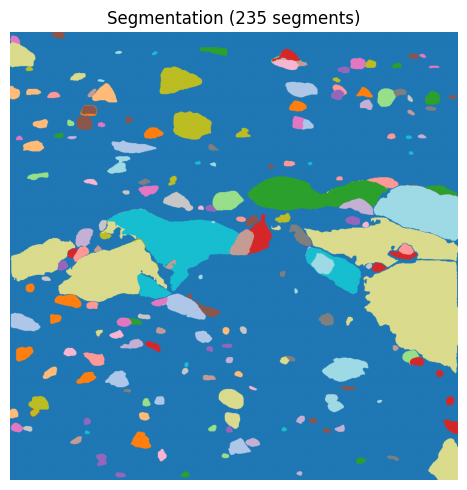

In [4]:
plot_result(result, show_segments=True, show_rois=False, show_spectra=False, figsize=(5, 5))

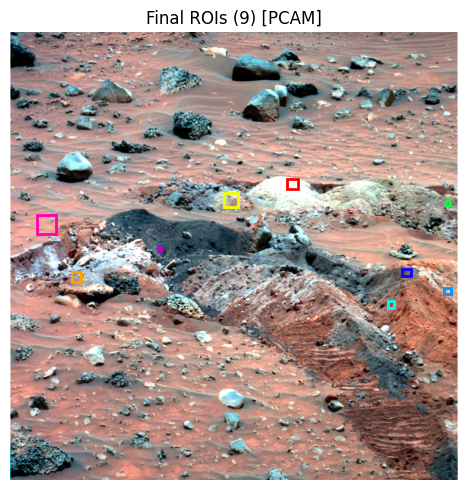

In [5]:
plot_result(result, show_segments=False, show_rois=True, show_spectra=False, figsize=(5, 5))

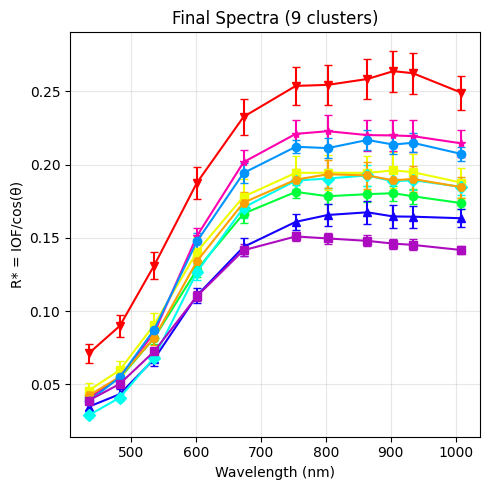

In [6]:
plot_result(result, show_segments=False, show_rois=False, show_spectra=True, figsize=(5, 5))

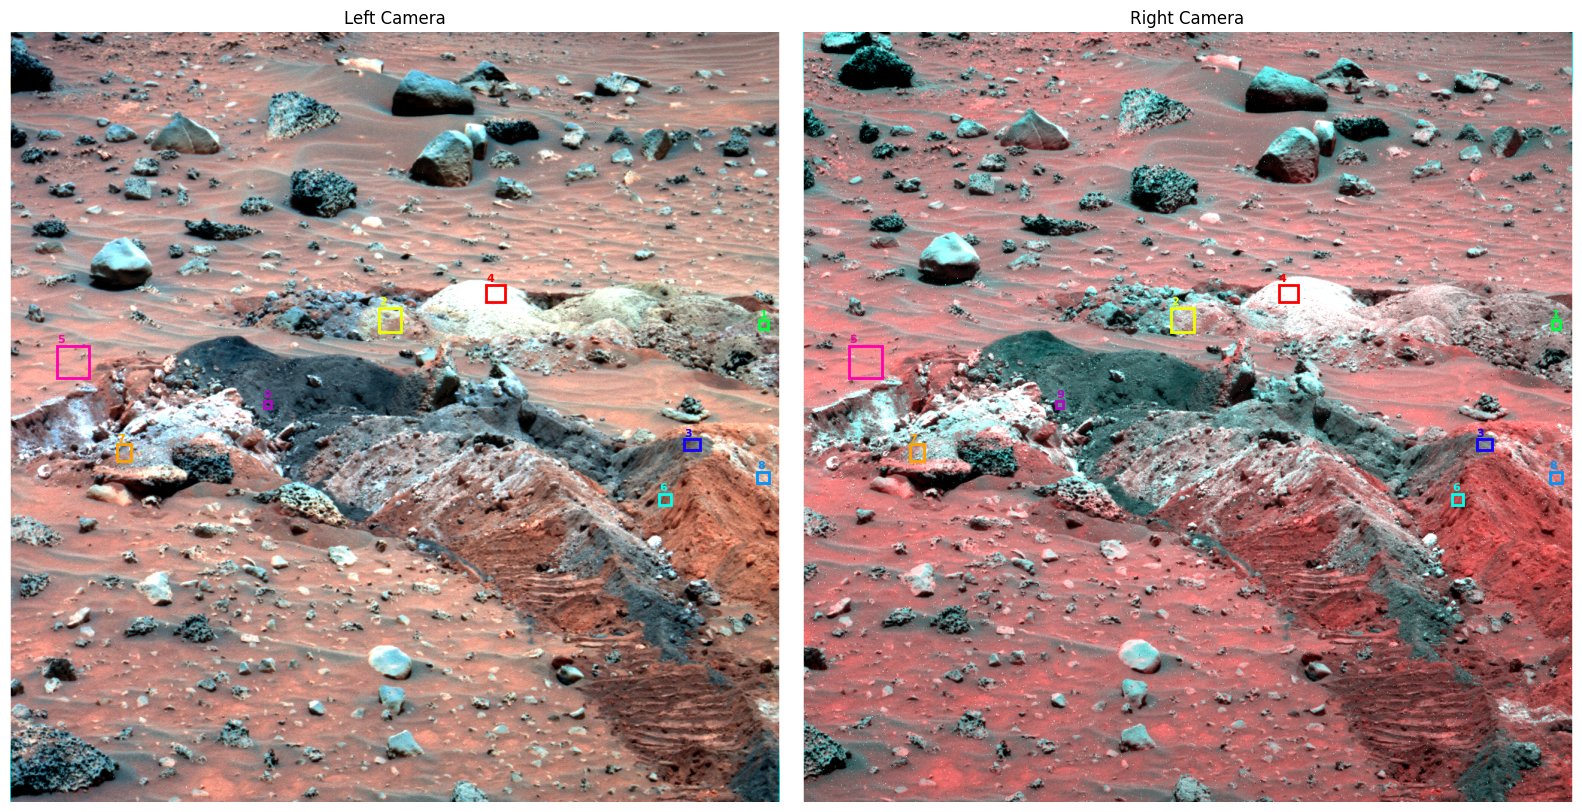

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from src.sparc.core.constants import COLORS

final_rois = result.final_rois

left_rgb  = state.load_result['left_rgb_img']
right_rgb = state.load_result['right_rgb_img']

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, img, title in zip(axes, [left_rgb, right_rgb], ['Left Camera', 'Right Camera']):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis('off')
    for i, (x, y, w, h) in enumerate(final_rois):
        color = COLORS[i % len(COLORS)]
        ax.add_patch(patches.Rectangle(
            (x, y), w, h,
            edgecolor=color,
            facecolor='none',
            linewidth=2
        ))
        ax.text(x, y - 4, str(i + 1), color=color, fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()